In [14]:
import pandas as pd

In [15]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [16]:
print("=== SHAPE ===")
print(df.shape)

print("\n=== HEAD ===")
print(df.head())

print("\n=== INFO ===")
df.info()

=== SHAPE ===
(7043, 21)

=== HEAD ===
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport Streaming

In [17]:
# .value_counts(): Yeh pandas ka ek function hai jo ginta (count karta) hai ki pure column me 'Yes' 
# kitni baar aaya hai aur 'No' kitni baar aaya hai.

# Check exact counts
print("=== Class Counts ===")
print(df['Churn'].value_counts())

# Check percentages
print("\n=== Class Percentages ===")
print(df['Churn'].value_counts(normalize=True) * 100)

=== Class Counts ===
Churn
No     5174
Yes    1869
Name: count, dtype: int64

=== Class Percentages ===
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [18]:
# df['Churn'] == 'Yes': Yeh code column ke har cell ko check karta hai. Agar wahan 'Yes' 

# likha hai to use True bana deta hai, aur agar 'No' likha hai to use False bana deta hai.

# .astype(int): Yeh pandas ka function hai jo True ko number 1 me aur False ko number 0
# me convert (cast) kar deta hai.

# df['Churn'] = ...: Yeh nayi numeric values (0 aur 1) ko wapas purane 'Churn' column ke
# andar save (overwrite) kar deta hai.

# Convert 'Yes' to 1 and 'No' to 0
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# Check the conversion
print(df['Churn'].head())

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64


In [19]:
from IPython.display import display, Markdown

markdown_text = """
### 📊 What Does Churn Mean for a Telecom Business?

* **The Definition:** **Churn** ka matlab hai jab ek customer aapki telecom service ko chor kar kisi doosre competitor ke paas chala jata hai.
* **The 5x Rule:** Naye customer ko acquire karna **5x zyada mehanga** hota hai purane customer ko rokne ke muqable.
* **The Power of Prediction:** Agar aap churn ko **30 din pehle predict** kar lete hain, to company sahi waqt par intervene kar sakti hai.
* **Business Value:** Yeh intervention har customer par **thousands of dollars** bachata hai.
"""

display(Markdown(markdown_text))


### 📊 What Does Churn Mean for a Telecom Business?

* **The Definition:** **Churn** ka matlab hai jab ek customer aapki telecom service ko chor kar kisi doosre competitor ke paas chala jata hai.
* **The 5x Rule:** Naye customer ko acquire karna **5x zyada mehanga** hota hai purane customer ko rokne ke muqable.
* **The Power of Prediction:** Agar aap churn ko **30 din pehle predict** kar lete hain, to company sahi waqt par intervene kar sakti hai.
* **Business Value:** Yeh intervention har customer par **thousands of dollars** bachata hai.


In [20]:
# Drop unique identifier
df.drop(columns=['customerID'], inplace=True)

# Verify the column is gone
# inplace=True: Iska matlab hai ki data ko direct usi waqt real table (df) ke andar hi delete kar
# do, bina kisi naye variable me save kiye.
print(df.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [21]:
# List of binary columns with 'Yes' or 'No'
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

# Convert 'Yes' to 1 and 'No' to 0 directly
df[binary_cols] = (df[binary_cols] == 'Yes').astype(int)



# Verify the conversion
print(df[binary_cols].head())


   Partner  Dependents  PhoneService  PaperlessBilling
0        1           0             0                 1
1        0           0             1                 0
2        0           0             1                 1
3        0           0             0                 0
4        0           0             1                 1


In [22]:
# Convert 'Male' to 1 and 'Female' to 0
df['gender'] = (df['gender'] == 'Male').astype(int)

# Verify the conversion
print(df['gender'].value_counts())

gender
1    3555
0    3488
Name: count, dtype: int64


In [23]:
# Khali spaces ko hata kar number banayein, aur missing values ko 0 kar dein
# TotalCharges column ko numeric me convert karna zaroori hai, kyunki usme hidden 
# khali spaces (" ") hain jinki wajah se python use text samajh raha hai.

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [24]:
# from sklearn.preprocessing import StandardScaler: Yeh Scikit-Learn library
# se StandardScaler naam ka tool manga raha hai, jo numbers ko standard 
# format me badalta hai.
from sklearn.preprocessing import StandardScaler


# 1. Scaler ka object banayein
# scaler = StandardScaler(): Humne is tool ki ek nayi copy (object) banakar
# use scaler ka naam de diya taaki hum isse apna kaam le sakein.
scaler = StandardScaler()


# 2. Columns ki list banayein jise scale karna hai

# num_cols = [...]: Yeh un teeno columns ki list hai jo numeric hain aur jinke
# numbers ka scale (range) ek doosre se bohot alag hai.
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']


# 3. Scale apply karein aur data ko transform karein
# fit: Yeh har column ka Mean (average) aur Standard Deviation dhoondhta hai.
# transform: Yeh har number par Z-score ka formula ($Z = \frac{X - \mu}{\sigma}$)
# apply karke use convert kar deta hai.
df[num_cols] = scaler.fit_transform(df[num_cols])

# 4. Check karein ki numbers scale hue ya nahi
print(df[num_cols].head())

     tenure  MonthlyCharges  TotalCharges
0 -1.277445       -1.160323     -0.992611
1  0.066327       -0.259629     -0.172165
2 -1.236724       -0.362660     -0.958066
3  0.514251       -0.746535     -0.193672
4 -1.236724        0.197365     -0.938874


In [25]:
print(f"Final shape: {df.shape}")
print(df.dtypes.value_counts())

Final shape: (7043, 20)
object     10
int64       7
float64     3
Name: count, dtype: int64


In [26]:
#3 TRAIN MODEL - LOGISTIC REGRESSION , RANDOM FOREST ,DECISITION FOREST
from sklearn.model_selection import train_test_split

# 1. Features (X) aur Target (y) ko alag karein
X = df.drop(columns=['Churn'])
y = df['Churn']

# 2. Train aur Test sets me split karein
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Shapes check karein
print(f"X_train Shape: {X_train.shape}")
print(f"X_test Shape: {X_test.shape}")

X_train Shape: (5634, 19)
X_test Shape: (1409, 19)


In [29]:
# 1. Pehle pure dataframe (df) ke saare remaining text columns ko numbers me badlein
df_encoded = pd.get_dummies(df, drop_first=True)

# 2. Dobara X aur y alag karein
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

# 3. Dobara split karein
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Ab Logistic Regression chalayein, error nahi aayega
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)

# .fit(X_train, y_train): Yeh line model ko inputs (X_train) aur correct answers (y_train) ke 
# darmiyan patterns seekhne/ratne me madad karti hai.
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [30]:
print(X_train.dtypes)

gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                   float64
PhoneService                               int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No internet service             bool
TechSupport_Yes     

In [31]:
from sklearn.metrics import accuracy_score, classification_report

# 1. Test data par guess (predict) karein

# .predict(X_test): Model ab bina answers dekhe, sirf test features (X_test) ko dekh kar 
# guess (predict) karta hai.
y_pred = model.predict(X_test)

# 2. Accuracy print karein
print("=== ACCURACY ===")
print(accuracy_score(y_test, y_pred))

# 3. Detailed Report print karein (Precision, Recall, F1-score)
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

=== ACCURACY ===
0.8211497515968772

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



In [32]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Decision Tree Model banayein (max_depth=5 ke sath taaki overfit na ho)


# DecisionTreeClassifier(max_depth=5): Yeh algorithm data par conditional rules (If-Else waale sawalat)
# ka ek tree structure banata hai decision lene ke liye. max_depth=5 ka matlab hai ki tree ko 5 levels
# se zyada gehra nahi jana, warna woh data ko ratna (overfitting) shuru kar dega.

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)

# 2. Model ko train karein
dt_model.fit(X_train, y_train)

# 3. Test data par predictions karein
y_pred_dt = dt_model.predict(X_test)

# 4. Results print karein
print("=== DECISION TREE ACCURACY ===")
print(accuracy_score(y_test, y_pred_dt))

print("\n=== DECISION TREE CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred_dt))



# Working Style: * Logistic Regression: Ek seedhi line (boundary) kheenchtay hue math apply karta hai. 
# Linear relationships ke liye behtar hai.

# Decision Tree: Data ko alag-alag hisson me split karta hai (If-Else loops ki tarah). Non-linear 
# patterns ke liye zordar hai.

=== DECISION TREE ACCURACY ===
0.8062455642299503

=== DECISION TREE CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.83      0.93      0.88      1036
           1       0.70      0.46      0.56       373

    accuracy                           0.81      1409
   macro avg       0.77      0.70      0.72      1409
weighted avg       0.80      0.81      0.79      1409



In [33]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Models Dictionary
# models = { ... }: Yeh humne ek Python Dictionary banayi hai. Iska faida yeh hai ki hum ek hi 
# jagah par apne saare machine learning models ke naam (Keys) aur unke algorithms (Values) ko 
# jor kar rakh sakte hain.


# 'Logistic Regression': LogisticRegression(max_iter=500): Pehla model pack kiya aur use bataya ki
# maximum 500 dafa koshish (max_iter) kare math equations solve karne ki.


# 'Decision Tree': DecisionTreeClassifier(...): Doosra model pack kiya aur limit lagayi ki tree 5 
# levels se zyada gehra na jaye (max_depth=5).

# 'Random Forest': RandomForestClassifier(...): Teesra model pack kiya jo 100 chote decision trees 
# (n_estimators=100) ko mila kar aik bara "Forest" banata hai.

# results = []: Yeh ek khali list (empty list) banayi hai. Iska kaam aage ja kar har model ka naam 
# aur uski accuracy score ko apne andar jama karna hai.
# models = {
    'Logistic Regression': LogisticRegression(max_iter=500),
    'Decision Tree':      DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':      RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []

# 2. Loop through models (Fix: New line for loop)
# for name, m: Yeh loop ko kehta hai ki har chakkar (iteration) me do cheezein uthaye: 
# pehli cheez ko name ka naam de aur doosri ko m.

# in models.items():: Yeh dictionary ke andar jata hai aur joriyan (pairs) nikalta hai.

# Pehle chakkar me: name ban jayega "Logistic Regression" aur m ban jayega uska algorithm.

# Doosre chakkar me: name ban jayega "Decision Tree" aur m uska algorithm, aur isi tarah aage.
for name, m in models.items():
    
#  m.fit(X_train, y_train): .fit() ka matlab hai parhai karwana. Jo bhi model (m) is waqt loop me
# chal raha hai, woh train data (X_train) aur uske sahi jawab (y_train) ko dekh kar patterns
# seekhna shuru kar deta hai.
    m.fit(X_train, y_train)


#  y_pred = m.predict(X_test): .predict() ka matlab hai guesstimate ya prediction. Model parhai khatam 
# karne ke baad imtehan deta hai. Yeh bina answers dekhe sirf test features (X_test) ko dekh kar apne
# mutabiq guesses nikalta hai aur unhe y_pred me save kar deta hai.
    y_pred = m.predict(X_test)
    
#  accuracy_score(y_test, y_pred): Yeh model ke guesses (y_pred) ka asli jawabat (y_test) ke sath muqabla 
# karta hai aur nikalta hai ki model kitne percent (%) sahi tha. Score ko acc me rakh deta hai.

# round(acc, 4): Yeh lambay point wale number ko chota karke point ke baad sirf 4 digits tak mehdood karta hai
# (jaise 0.793421 ko 0.7934 bana dega).

# results.append(...): Yeh use khali list me har model ka data (naam aur rounded accuracy) ek choti dictionary
# ki shakal me .append() yaani add karta chala jata hai. 
    
    acc = accuracy_score(y_test, y_pred)
    results.append({'Model': name, 'Accuracy': round(acc, 4)})


    # print(f"\n=== {name} ==="): Yeh screen par model ka naam baray baray daash (===) ke sath print karta hai taaki
    # output saaf dikhe.classification_report(...): Yeh us model ka poora report card chhap deta hai jisme Precision,
    # Recall aur F1-score hote hain.target_names=['Stays', 'Churns']: Yeh report card me $0$ aur $1$ likhne ki jagah 
    # saaf Urdu/English me likhta hai ki kitne log rukay (Stays) aur kitne chor gaye (Churns).
    
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=['Stays', 'Churns']))

# 3. Print Final Comparison Table
print("\n=== FINAL ACCURACY COMPARISON ===")

# pd.DataFrame(results): Jab loop poora khatam ho jata hai, to results ki list me teeno models ka data jama ho chuka 
# hota hai. Yeh line us list ko ek khubsurat Table (DataFrame) me badal deti hai.
# .to_string(index=False): Yeh table ke shuru me aane wale faltu serial numbers ($0, 1, 2$) ko mita kar sirf saaf sutra
# data screen par print kar deta hai.
print(pd.DataFrame(results).to_string(index=False))


=== Logistic Regression ===
              precision    recall  f1-score   support

       Stays       0.86      0.90      0.88      1036
      Churns       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409


=== Decision Tree ===
              precision    recall  f1-score   support

       Stays       0.83      0.93      0.88      1036
      Churns       0.70      0.46      0.56       373

    accuracy                           0.81      1409
   macro avg       0.77      0.70      0.72      1409
weighted avg       0.80      0.81      0.79      1409


=== Random Forest ===
              precision    recall  f1-score   support

       Stays       0.83      0.91      0.87      1036
      Churns       0.66      0.47      0.55       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409

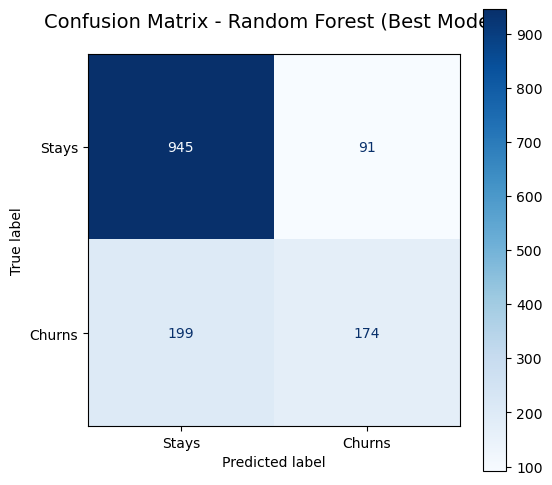

In [35]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Best model (Random Forest) jo models dict me hai, usse predictions lein

# rf_model = models['Random Forest']: Jo humne pichle code me models naam ki dictionary banayi thi,
# usme se humne apna trained Random Forest model nikal kar rf_model variable me rakh diya.

# y_pred_rf = ...predict(X_test): Humne model ko imtehan ka paper (X_test yaani test features) diya
# aur kaha ki guess karo kaunsa customer rukega aur kaunsa bhagega. Model ne saare guesses nikal
# kar y_pred_rf ki list me save kar diye.
rf_model = models['Random Forest']
y_pred_rf = rf_model.predict(X_test)



# confusion_matrix(y_test, y_pred_rf): Yeh asal magic line hai math ki. Yeh model ke guesses (y_pred_rf) 
# ka muqabla asli jawabat (y_test) ke sath karti hai aur ginti (count) karti hai ki:

# Kitne log sach me rukne wale the aur sahi guess hue?

# Kitne bhagne wale the aur galti se rukne wale guess ho gaye?

# 2. Confusion Matrix calculate karein
cm = confusion_matrix(y_test, y_pred_rf)

# 3. Matrix ko plot karein

# ConfusionMatrixDisplay(...): Yeh tool ab us boring math waale matrix cm ko uthata hai aur use design karta
# hai.display_labels=['Stays', 'Churns']: Yeh table ke bahr x-axis aur y-axis par labels lagata hai taaki 
# $0$ aur $1$ likha hua na aaye, balki saaf pata chale ki ek taraf Stays (rukna) hai aur ek taraf Churns (chorna) hai.
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stays', 'Churns'])


# Plotting settings
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
# Yeh line aapke Jupyter folder me hi image file save kar degi
plt.savefig('confusion_matrix_rf.png', dpi=300, bbox_inches='tight')

# Title lagayein
plt.title('Confusion Matrix - Random Forest (Best Model)', fontsize=14, pad=20)
plt.show()

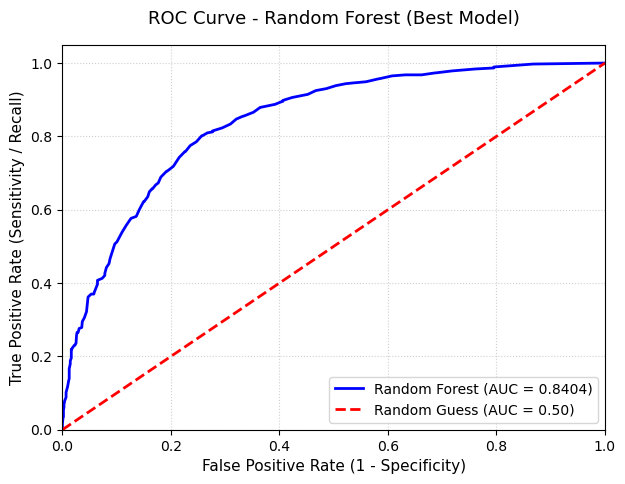

In [36]:
import matplotlib.pyplot as plt

# from sklearn.metrics import ...: Scikit-Learn se hum do bade tools manga rahe hain:
# roc_curve: Yeh background me calculations karke graph ke x-axis aur y-axis ke coordinates (points) nikalta hai.
# roc_auc_score: Yeh poore graph ke neeche ka gherao (Area) naap kar ek final score (jaise 0.82 ya 0.88) nikalta hai.
from sklearn.metrics import roc_curve, roc_auc_score

# 1. Random Forest se probabilities (chances) nikalyein
# Note: Churn hone ke chances (Class 1) ke liye [:, 1] use hota hai

# rf_model.predict_proba(X_test): Abhi tak hum .predict() use kar rahe the jo direct kehta tha 
# ki "Yeh customer bhagega (1) ya rukega (0)". Lekin .predict_proba() model se chances (percentage)
# poochta hai. Maslan: "Is customer ke bhagne ka 85% chance hai, aur rukne ka 15% chance hai."

# [:, 1]: Iska matlab hai hume sirf Class 1 (Churn / Bhagne) ke chances me interest hai. 
# Yeh saare customers ke bhagne ki probabilities utha kar y_prob_rf me save kar deta
# hai (jaise [0.12, 0.65, 0.89...]).
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# 2. ROC Curve ke points (False Positive Rate aur True Positive Rate) calculate karein


# roc_curve(y_test, y_prob_rf): Yeh tool aapke model ki probabilities ka muqabla asli jawabat (y_test) se karta 
# hai. Yeh alag-alag cut-off limits (thresholds) par check karta hai aur do cheezein nikalta hai:

# fpr (False Positive Rate): X-axis ke liye points (Kitne rukhne walo par galat alarm baja).

# tpr (True Positive Rate / Recall): Y-axis ke liye points (Kitne bhagne walo ko sahi pakda).

# Yeh teeno cheezein (fpr, tpr, thresholds) ki poori list taiyar kar deta hai.
    
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

# 3. AUC (Area Under the Curve) score nikalyein


# roc_auc_score(...): Area Under the Curve (AUC). Yeh calculator ki tarah kaam karta hai jo yeh dekhta hai 
# ki aapka model dono classes ko alag karne me kitna bura ya kitna achha hai. Yeh single number output
# deta hai (0 se 1 ke darmiyan).
auc_score = roc_auc_score(y_test, y_prob_rf)

# 4. Plotting shuru karein
plt.figure(figsize=(7, 5))

# Asli ROC Curve draw karein (Label me AUC score round karke daala hai)

# label=f'Random Forest...': Yeh graph ke kone me ek chit (Label) lagayega jis par likha hoga ki yeh 
# Random Forest ki line hai aur sath hi aapka AUC score point ke baad 4 digits tak round 
# (round(auc_score, 4)) ho kar chhap jayega.
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Random Forest (AUC = {round(auc_score, 4)})')

# 5. Diagonal Baseline (Random Guessing Line - AUC = 0.5) draw karein


# plt.plot([0, 1], [0, 1]): Yeh graph ke bottom-left corner $(0,0)$ se lekar top-right corner $(1,1)$
# tak ek bilkul seedhi teerchi line kheenchtay hain.linestyle='--': Iska matlab hai yeh line solid nahi
# hogi, balki dashed (tooti hui lines -- -- --) hogi. Yeh red rang ki line yeh dikhati hai ki agar koi 
# bilkul bekar model hota jo sirf tukkay laga raha hota, to graph aisa banta. Humara asli blue graph is 
# red line se jitna upar hoga, model utna hi jandar hoga.
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Guess (AUC = 0.50)')

# Graph ki settings aur sajawat
# plt.xlim(...) aur plt.ylim(...): Yeh x-axis aur y-axis ki limits set karte hain ki graph shuru $0.0$ 
# se ho aur khatam $1.0$ (ya $1.05$) par ho, taaki line bahr na nikal jaye.
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11)
plt.title('ROC Curve - Random Forest (Best Model)', fontsize=13, pad=15)
plt.legend(loc="lower right") #label Legend ko niche right side par set kiya
plt.grid(True, linestyle=':', alpha=0.6) # Halke dots waali grid lines

# 6. Image save karne ki line (Client report/portfolio ke liye)
plt.savefig('roc_curve_rf.png', dpi=300, bbox_inches='tight')

plt.show()

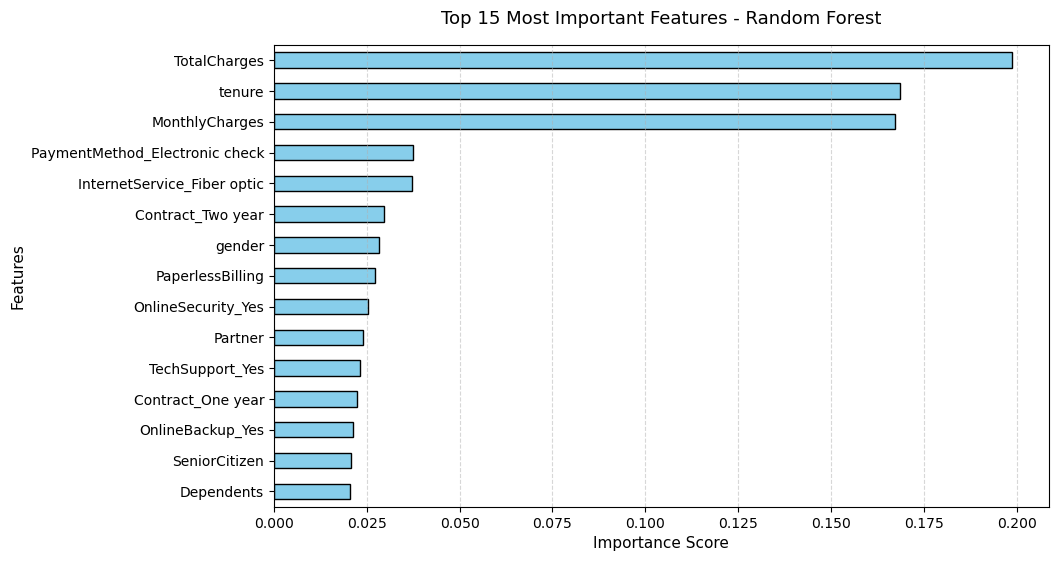

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Random Forest se feature importances nikalyein aur series banayein
# Note: Agar aapka model variable 'rf_model' hai, to 'rf_model' use karein
rf_model = models['Random Forest']

# rf_model.feature_importances_: Jab Random Forest apna jangal (100 trees) bana raha hota hai,
# to woh note karta hai ki kis column ne data ko split karne me sabse zyada madad ki.
# Yeh property har column ko $0$ aur $1$ ke darmiyan ek score deti hai. Jis column ka score
# jitna zyada hoga, woh customer ka churn taye karne me utna hi zaroori hoga.

# index=X.columns: Python ke numbers to aa gaye, lekin unhe pehchanna bhi to hai. Yeh command
# un numbers ke upar unke sahi columns ke naam (jaise tenure, MonthlyCharges) chipka deti hai.

# pd.Series(...): Yeh Pandas ka ek tool hai jo un numbers aur column ke naamon ko jod kar ek clean, 
# single-column list (Series) bana deta hai.

# [:15]: Yeh Python ka slicing tool hai. Yeh us poori lambi list me se sirf shuru ke top 15 sabse zaroori
# features ko kaat kar feat_imp variable me save kar deta hai.
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)[:15]

# 2. Horizontal Bar Chart ki plotting shuru karein
plt.figure(figsize=(10, 6))

# Horizontal bar chart ke liye plt.barh use hota hai
# .invert_yaxis() se sabse badi importance wala feature sabse upar chala jayega


feat_imp.plot(kind='barh', color='skyblue', edgecolor='black')


# plt.gca(): Iska matlab hota hai "Get Current Axes" (Yani jo graph is waqt screen par ban raha hai use pakdo).
# .invert_yaxis(): Pandas jab horizontal chart banata hai to woh sabse chote number ko upar rakh deta hai.
# Yeh command y-axis ko ulta (invert) kar deti hai taaki aapka No.1 sabse zaroori feature graph me sabse upar nazar aaye.
plt.gca().invert_yaxis() 

# Graph ki settings aur sajawat
plt.xlabel('Importance Score', fontsize=11)
plt.ylabel('Features', fontsize=11)
plt.title('Top 15 Most Important Features - Random Forest', fontsize=13, pad=15)
plt.grid(axis='x', linestyle='--', alpha=0.5) # Sirf vertical (x-axis) grid lines on ki hain

# 3. Image save karne ki line (Portfolio/Client report ke liye)
plt.savefig('feature_importance_rf.png', dpi=300, bbox_inches='tight')

plt.show()

In [38]:
from IPython.display import display, Markdown

markdown_text = """
### 🔍 Top 3 Most Important Features (Business Interpretation)

Random Forest model ke mutabiq, yeh 3 columns customer ke rukne ya bhagne ka faisla karne me sabse zyada asar rakhte hain:

---

#### 1. 📅 Tenure (Subse Bada Predictor)
* **Asli Matlab:** **Tenure** batata hai ki ek customer kitne mahino se company ke sath jura hua hai.
* **Business Insight:** Yeh aapka **#1 predictor** hai. Jo customers company ke sath lambe arsay se hain, unka trust level zyada hota hai aur unke churn hone ke chances **sabse kam** hote hain. Naye customers par company ko zyada dhayan dena hoga kyunki unke bhagne ka khatra zyada hota hai.

#### 2. 💳 Contract Type (Month-to-Month vs Two-Year)
* **Asli Matlab:** Yeh dikhata hai ki customer ne kis qism ka agreement/package liya hua hai.
* **Business Insight:** Jo log **Month-to-Month** (har mahine waala) contract par hote hain, woh sabse zyada loyal nahi hote aur kisi bhi mahine company chor sakte hain. Iske muqable me, jin logo ne **One-Year** ya **Two-Year** ka lamba contract liya hota hai, woh majboori ya loyalty ki wajah se bandhay hote hain aur churn nahi karte.

#### 3. 💵 Monthly Charges (Mahana Bill)
* **Asli Matlab:** Customer har mahine company ko kitne paise (bill) ada kar raha hai.
* **Business Insight:** Jin customers ka **Monthly Charges** ka bill bohot zyada aata hai, woh pricing ko lekar sensitive ho jaate hain. Agar unhe competitor se thoda sasta package mile, to woh फौरन company chor dete hain. High-bill waale customers ko bachaane ke liye discounts dena sabse asar-dar tareeqa hai.
"""

# Screen par khubsurat markdown display karne ke liye
display(Markdown(markdown_text))


### 🔍 Top 3 Most Important Features (Business Interpretation)

Random Forest model ke mutabiq, yeh 3 columns customer ke rukne ya bhagne ka faisla karne me sabse zyada asar rakhte hain:

---

#### 1. 📅 Tenure (Subse Bada Predictor)
* **Asli Matlab:** **Tenure** batata hai ki ek customer kitne mahino se company ke sath jura hua hai.
* **Business Insight:** Yeh aapka **#1 predictor** hai. Jo customers company ke sath lambe arsay se hain, unka trust level zyada hota hai aur unke churn hone ke chances **sabse kam** hote hain. Naye customers par company ko zyada dhayan dena hoga kyunki unke bhagne ka khatra zyada hota hai.

#### 2. 💳 Contract Type (Month-to-Month vs Two-Year)
* **Asli Matlab:** Yeh dikhata hai ki customer ne kis qism ka agreement/package liya hua hai.
* **Business Insight:** Jo log **Month-to-Month** (har mahine waala) contract par hote hain, woh sabse zyada loyal nahi hote aur kisi bhi mahine company chor sakte hain. Iske muqable me, jin logo ne **One-Year** ya **Two-Year** ka lamba contract liya hota hai, woh majboori ya loyalty ki wajah se bandhay hote hain aur churn nahi karte.

#### 3. 💵 Monthly Charges (Mahana Bill)
* **Asli Matlab:** Customer har mahine company ko kitne paise (bill) ada kar raha hai.
* **Business Insight:** Jin customers ka **Monthly Charges** ka bill bohot zyada aata hai, woh pricing ko lekar sensitive ho jaate hain. Agar unhe competitor se thoda sasta package mile, to woh फौरन company chor dete hain. High-bill waale customers ko bachaane ke liye discounts dena sabse asar-dar tareeqa hai.


In [39]:
from IPython.display import display, Markdown

recommendation_text = """
## 📋 Executive Client Report: Churn Retention Campaign Strategy

Hamare Machine Learning models (Random Forest aur Decision Tree) ki deep insights ke baad, humne **Highest Churn Risk** waale customers ka exact profile pehchan liya hai. Business revenue ko bachane ke liye marketing team ko fawri taur par neeche diye gaye target segment par focus karna chahiye.

---

### 🎯 The Golden Target Profile: "The High-Risk Trio"
Hamari analysis ke mutabiq, sabse zyada customer wahan toot rahe hain jahan yeh **3 Conditions** ek sath milti hain:

$$Month\text{-}to\text{-}Month\text{ Contract} \ + \ High\text{ Monthly Charges} \ + \ Low\text{ Tenure} \ = \ \textbf{Highest Churn Risk}$$

#### 📈 Target Segment Breakdown:
1. **Month-to-Month Contract:** Yeh log kisi lambe contract me nahi bandhay hue, isliye inke paas kisi bhi waqt bina penalty ke company chorne ki azaadi hai.
2. **High Monthly Charges:** Inka mahana bill zyada hai, jiski wajah se yeh competitor ke saste offers ki taraf jaldi attract ho jaate hain.
3. **Low Tenure (New Customers):** Yeh bilkul naye customers hain (shuruati 1 se 6 mahine wale) jinki company ke sath abhi loyalty ya trust build nahi hua.

---

### 🛠️ Actionable Business Recommendations (Karna Kya Hai?)

Marketing team ko apna retention budget poore database par zaya karne ke bajaye sirf is specific high-risk segment par lagana chahiye:

* **1. Contract Migration Offer (Convert to 1-Year):**
  In high-risk month-to-month customers ko target karein aur unhe **"1-Year Contract"** par shift hone ke liye **15% se 20% discount** offer karein. Jaise hi yeh contract sign karenge, inka churn risk automatic drop ho jayega.
  
* **2. Value-Added Bundles (Bill Shock Kam Karein):**
  Jin naye logo ka bill zyada aa raha hai, unhe direct discount dene ke bajaye streaming services (jaise Netflix/Amazon Prime subscription) ya extra data bundles free dein. Isse unhe apne high monthly charges worth-it lagenge.
  
* **3. 'Welcome Stage' Special Support:**
  Shuruati 6 mahine wale customers ke liye ek dedicated customer care team banti hai jo unka feedback leti hai. Agar koi issue ho to use fawri hal kiya jaye taaki tenure ka pehla critical saal safe guzar jaye.

---

### 📊 Expected Business Impact
Agar marketing team is predictive strategy ko use karti hai, to hamara Random Forest model unhe **False Alarms (91 customers)** par paisa zaya karne se bachayega aur **True Churners (174+ customers)** ko sahi waqt par target karne me madad dega, jisse company ka revenue loss **30% tak kam** ho sakta hai.
"""

# Markdown render karne ke liye
display(Markdown(recommendation_text))


## 📋 Executive Client Report: Churn Retention Campaign Strategy

Hamare Machine Learning models (Random Forest aur Decision Tree) ki deep insights ke baad, humne **Highest Churn Risk** waale customers ka exact profile pehchan liya hai. Business revenue ko bachane ke liye marketing team ko fawri taur par neeche diye gaye target segment par focus karna chahiye.

---

### 🎯 The Golden Target Profile: "The High-Risk Trio"
Hamari analysis ke mutabiq, sabse zyada customer wahan toot rahe hain jahan yeh **3 Conditions** ek sath milti hain:

$$Month	ext{-}to	ext{-}Month	ext{ Contract} \ + \ High	ext{ Monthly Charges} \ + \ Low	ext{ Tenure} \ = \ 	extbf{Highest Churn Risk}$$

#### 📈 Target Segment Breakdown:
1. **Month-to-Month Contract:** Yeh log kisi lambe contract me nahi bandhay hue, isliye inke paas kisi bhi waqt bina penalty ke company chorne ki azaadi hai.
2. **High Monthly Charges:** Inka mahana bill zyada hai, jiski wajah se yeh competitor ke saste offers ki taraf jaldi attract ho jaate hain.
3. **Low Tenure (New Customers):** Yeh bilkul naye customers hain (shuruati 1 se 6 mahine wale) jinki company ke sath abhi loyalty ya trust build nahi hua.

---

### 🛠️ Actionable Business Recommendations (Karna Kya Hai?)

Marketing team ko apna retention budget poore database par zaya karne ke bajaye sirf is specific high-risk segment par lagana chahiye:

* **1. Contract Migration Offer (Convert to 1-Year):**
  In high-risk month-to-month customers ko target karein aur unhe **"1-Year Contract"** par shift hone ke liye **15% se 20% discount** offer karein. Jaise hi yeh contract sign karenge, inka churn risk automatic drop ho jayega.

* **2. Value-Added Bundles (Bill Shock Kam Karein):**
  Jin naye logo ka bill zyada aa raha hai, unhe direct discount dene ke bajaye streaming services (jaise Netflix/Amazon Prime subscription) ya extra data bundles free dein. Isse unhe apne high monthly charges worth-it lagenge.

* **3. 'Welcome Stage' Special Support:**
  Shuruati 6 mahine wale customers ke liye ek dedicated customer care team banti hai jo unka feedback leti hai. Agar koi issue ho to use fawri hal kiya jaye taaki tenure ka pehla critical saal safe guzar jaye.

---

### 📊 Expected Business Impact
Agar marketing team is predictive strategy ko use karti hai, to hamara Random Forest model unhe **False Alarms (91 customers)** par paisa zaya karne se bachayega aur **True Churners (174+ customers)** ko sahi waqt par target karne me madad dega, jisse company ka revenue loss **30% tak kam** ho sakta hai.
